# South African Crime Count Prediction
### Predicting provincial crime counts using Machine Learning

**Dataset:** Kaggle - crimes_incidents_by_category
**Models:** Linear Regression vs Random Forest
**Author:** Khutso Mashapu
**Date:** 2026

In [32]:
# Data Manipulation 
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [5]:
df = pd.read_csv("crime_incidents_by_category.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (840, 4)


,Geography,Crime Category,Financial Year,Count
0,ZA,Contact Crimes,2011/2012,615935
1,ZA,Contact Crimes,2012/2013,608724
2,ZA,Contact Crimes,2013/2014,611574
3,ZA,Contact Crimes,2014/2015,616973
4,ZA,Contact Crimes,2015/2016,623223


## 2. Exploratory Data Analysis

In [8]:
# Data types and null values
print("\nData Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Geography       840 non-null    object
 1   Crime Category  840 non-null    object
 2   Financial Year  840 non-null    object
 3   Count           840 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 26.4+ KB

Missing Values:
Geography         0
Crime Category    0
Financial Year    0
Count             0
dtype: int64

Duplicates:
0

Statistical Summary:


,Count
count,840.000000
mean,61766.336905
std,111240.587975
min,377.000000
25%,8083.000000
50%,24581.500000
75%,63066.750000
max,653659.000000


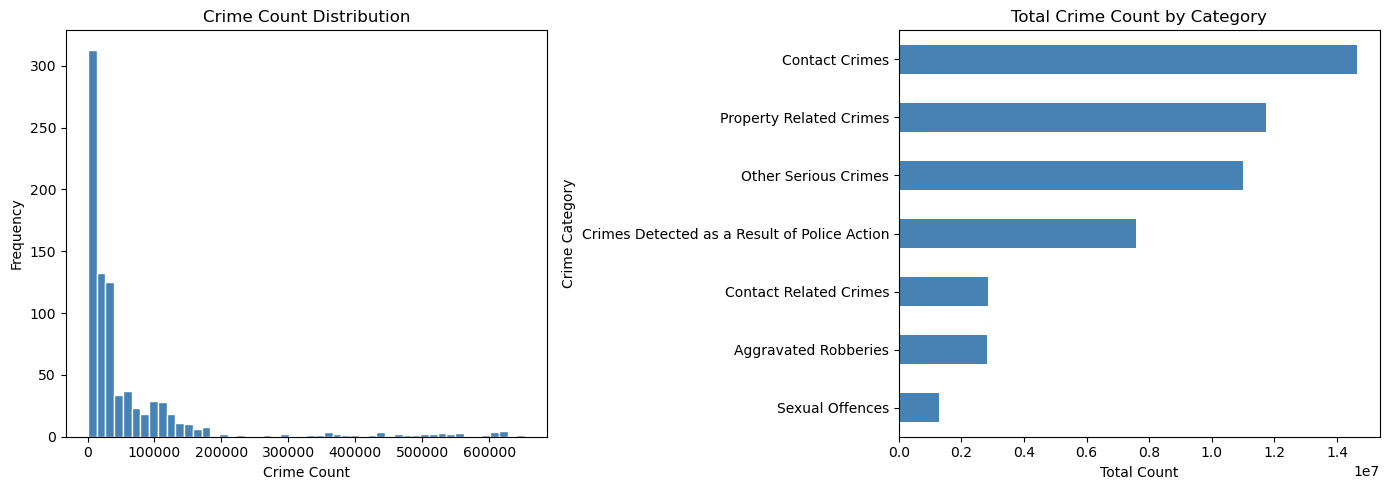

In [11]:
# Visualise crime count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['Count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Crime Count Distribution')
axes[0].set_xlabel('Crime Count')
axes[0].set_ylabel('Frequency')

# Crime by Category
df.groupby('Crime Category')['Count'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue'
)
axes[1].set_title('Total Crime Count by Category')
axes[1].set_xlabel('Total Count')

plt.tight_layout()
plt.show()

             

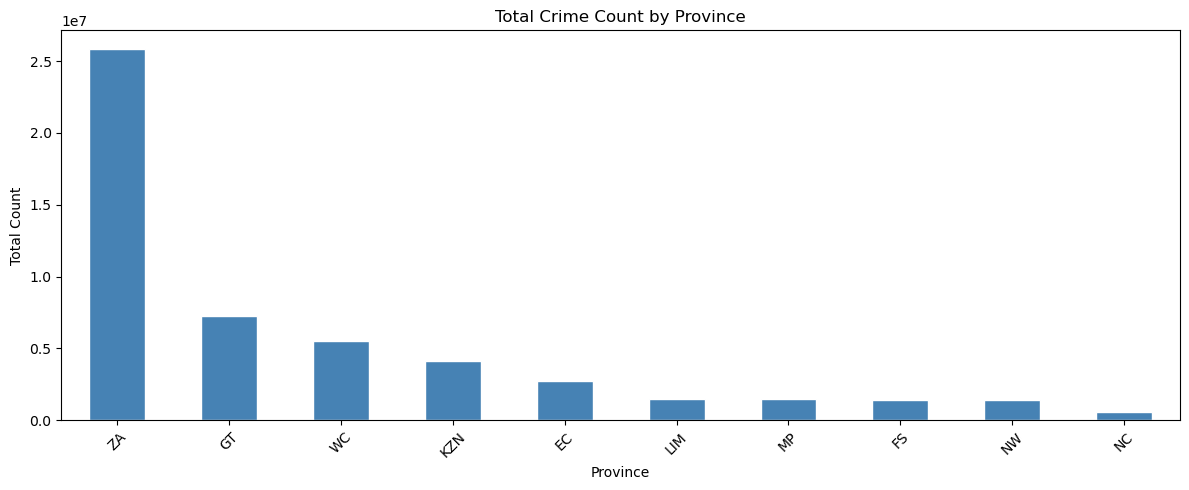

In [13]:
# Crime by Province
df.groupby('Geography')['Count'].sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white'
)
plt.title('Total Crime Count by Province')
plt.xlabel('Province')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

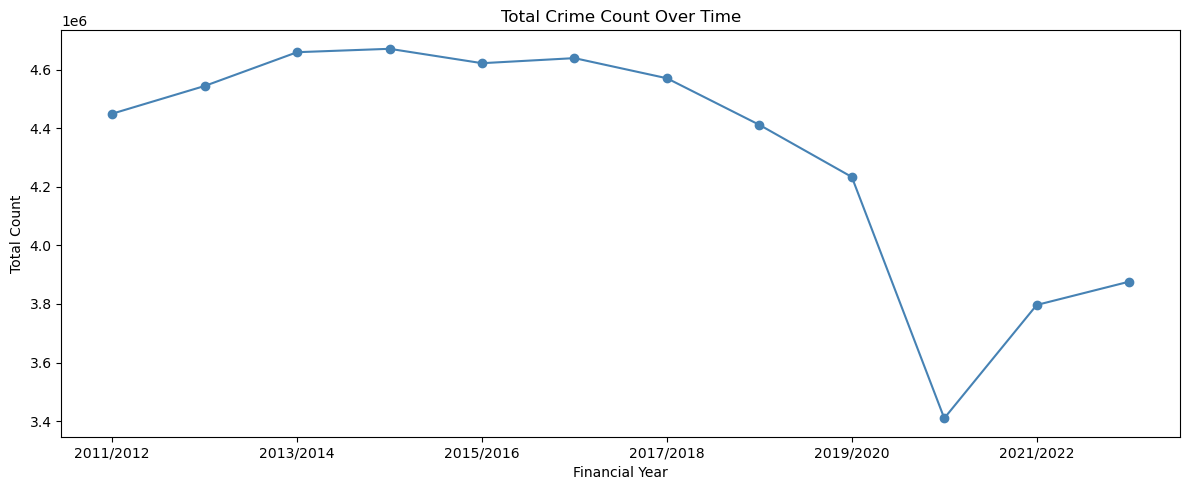

In [12]:
# Crime trend over time
df.groupby('Financial Year')['Count'].sum().plot(
    kind='line', figsize=(12, 5), color='steelblue', marker='o'
)
plt.title('Total Crime Count Over Time')
plt.xlabel('Financial Year')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [18]:
# Separate features and target
X = df.drop(columns=['Count'])
y = df['Count']

# Fix Finacial Year
X['Financial Year'] = X['Financial Year'].str[:4].astype(int)

# Encode categorical columns
X_encoded = pd.get_dummies(X, columns=['Geography', 'Crime Category'])

#Train test split
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")

Training set: (672, 18)
Test set: (168, 18)


## 4. Model Building
### Linear Regression

In [21]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

### Random Forest

In [25]:
rf = RandomForestRegressor(n_estimators=100, random_state=100)
rf.fit(x_train, y_train)
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

## 5. Model Evaluation

In [28]:
# Linear Regression metrics
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

# Random Forest metrics
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

results = pd.DataFrame([
    ['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2],
    ['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]],
    columns=['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2'])

results


,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,3.550458e+09,0.724849,2.900194e+09,0.714546
1,Random Forest,3.104037e+07,0.997594,3.066382e+07,0.996982


## 6. Visualisations

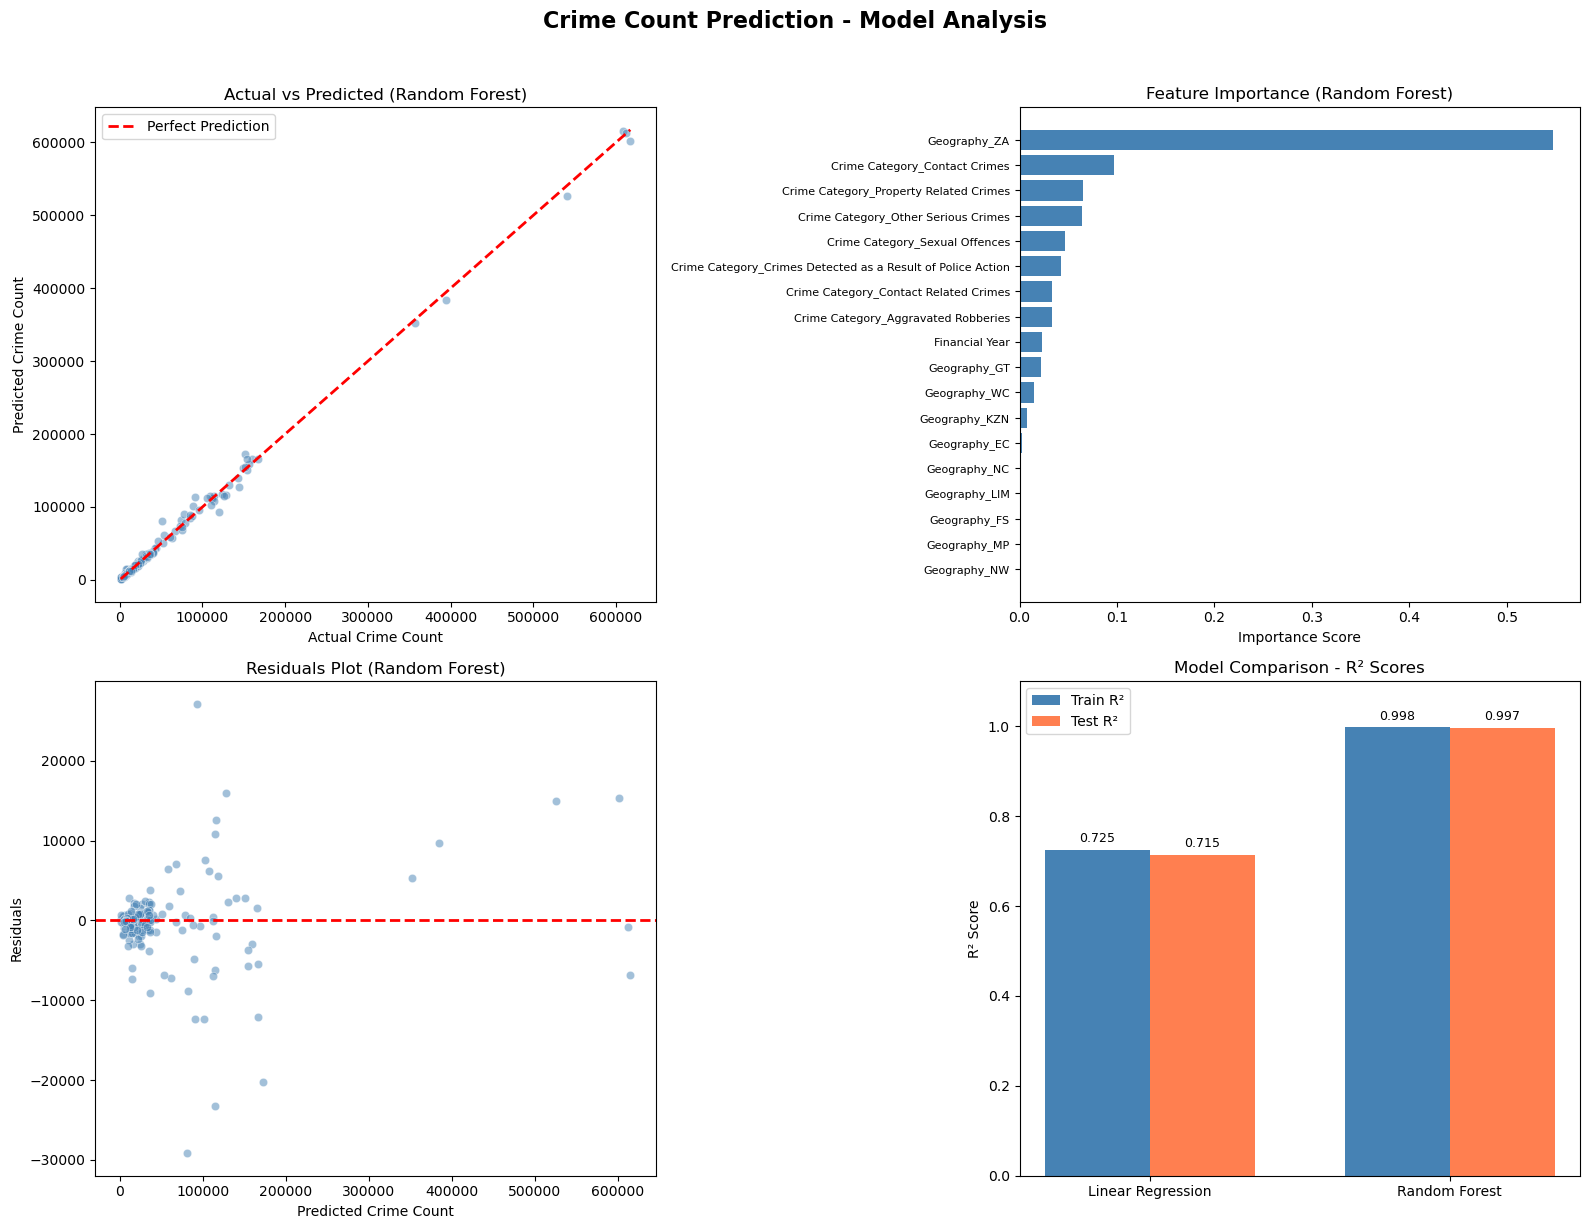

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Crime Count Prediction - Model Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. ACTUAL VS PREDICTED
ax1 = axes[0, 0]
ax1.scatter(y_test, y_rf_test_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Crime Count')
ax1.set_ylabel('Predicted Crime Count')
ax1.set_title('Actual vs Predicted (Random Forest)')
ax1.legend()

# 2. FEATURE IMPORTANCE
ax2 = axes[0, 1]
feature_names = x_train.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
ax2.barh(range(len(importances)), importances[indices], color='steelblue')
ax2.set_yticks(range(len(importances)))
ax2.set_yticklabels([feature_names[i] for i in indices], fontsize=8)
ax2.set_xlabel('Importance Score')
ax2.set_title('Feature Importance (Random Forest)')
ax2.invert_yaxis()

# 3. RESIDUALS PLOT
ax3 = axes[1, 0]
residuals = y_test - y_rf_test_pred
ax3.scatter(y_rf_test_pred, residuals, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Crime Count')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals Plot (Random Forest)')

# 4. MODEL COMPARISON BAR CHART
ax4 = axes[1, 1]
models = ['Linear Regression', 'Random Forest']
train_r2 = [lr_train_r2, rf_train_r2]
test_r2 = [lr_test_r2, rf_test_r2]
x = np.arange(len(models))
width = 0.35
bars1 = ax4.bar(x - width/2, train_r2, width, label='Train R²', color='steelblue')
bars2 = ax4.bar(x + width/2, test_r2, width, label='Test R²', color='coral')
ax4.set_ylabel('R² Score')
ax4.set_title('Model Comparison - R² Scores')
ax4.set_xticks(x)
ax4.set_xticklabels(models)
ax4.legend()
ax4.set_ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show() 

## 7. Conclusions

### Dataset
- The dataset contained **840 records** across 4 columns : Geography, Crime Category, 
  Financial Year and Crime Count
- Data was obtained from Kaggle: **crimes_incidents_by_category** and originally sourced from the **South African Police Service (SAPS)** crime statistics
- No missing values or duplicates were found, minimal preprocessing was required

### Model Performance
| Model | Train R² | Test R² |
|---|---|---|
| Linear Regression | 0.725 | 0.715 |
| Random Forest | 0.998 | 0.997 |

- **Random Forest significantly outperformed Linear Regression** achieving a Test R² 
  of 0.997 vs 0.715
- Random Forest explained **99.7% of the variance** in unseen crime count data
- The small gap between Random Forest Train R² (0.998) and Test R² (0.997) confirms 
  the model generalises well with minimal overfitting
- Linear Regression showed consistent but limited performance, explaining only 71.5% 
  of variance on unseen data

### Key Findings
- **Geography_ZA** (national aggregate) was the strongest predictor of crime count 
  with an importance score of ~0.52, suggesting national level patterns dominate 
  provincial level variation
- **Contact Crimes** was the most influential crime category, reflecting the 
  significant volume of assault, murder and robbery in South Africa
- **Property Related Crimes** was the second most important crime category
- **Individual provinces** (GT, WC, KZN etc.) had relatively low individual importance, 
  suggesting no single province dominates predictions in isolation
- **Financial Year had low importance**, crime counts have remained relatively 
  stable over the years with no dramatic shifts

### Why Random Forest Outperformed Linear Regression
- Crime count data is heavily skewed (min: 377, max: 653,659, mean: 61,766)
- Linear Regression assumes a straight line relationship between features and target, 
  which is too simplistic for this kind of skewed, non-linear data
- Random Forest builds 100 decision trees and combines their predictions, naturally 
  handling non-linear relationships and skewed distributions

### Implications
- Crime in South Africa is **highly predictable and structured**, geography, 
  crime category and financial year alone are sufficient to predict crime counts 
  with 99.7% accuracy
- The model could assist **law enforcement resource allocation** by predicting 
  which provinces and crime categories require more attention in future years
- The stability of Financial Year importance suggests that without significant 
  intervention, **crime patterns are likely to persist** into future years
- National level patterns matter more than individual provincial patterns, 
  suggesting a **coordinated national response** to crime may be more effective 
  than province-specific strategies